In [2]:
import pandas as pd
import os

# Define the path to the CSV file
csv_file_path = os.path.join('..', 'data', 'raw', '航道07102(2024-07-04).csv')  # Updated to use relative path

# Read the CSV file
data = pd.read_csv(csv_file_path, encoding='gbk')


In [3]:
data.describe()

,左转速(RPM),左水温(℃),左油压(MPa),左齿轮箱油压(MPa),左齿轮箱油温(℃),左推进累计时间(H),左推进电池电压(V),右转速(RPM),右水温(℃),右油压(MPa),...,甲板温度(℃),机舱温度(℃),左艉轴温度(℃),右艉轴温度(℃),油舱液位(M),剩余燃油体积(M3),剩余燃油重量(T),速度(节),GPS1经度(mm),GPS1纬度(mm)
count,17278.000000,17278.000000,17278.000000,17278.000000,17278.000000,17278.000000,17278.000000,17278.000000,17278.000000,17278.000000,...,17278.000000,17278.000000,17278.000000,17278.000000,17278.000000,17278.000000,17278.000000,17278.000000,17278.000000,17278.000000
mean,717.751013,38.070147,0.133528,1.120715,26.915905,5346.758016,13.857293,669.996122,41.556569,0.214684,...,32.491509,26.890323,34.567172,34.567172,0.705989,5.391934,4.524342,3.448624,112.437399,29.788598
std,777.156621,39.252220,0.140357,1.349260,27.743326,4.878077,14.105090,724.502166,43.082448,0.226944,...,3.599530,1.197670,7.373593,7.373593,0.350086,2.664684,2.238469,4.286924,0.069158,0.095050
min,0.000000,0.000000,0.000000,0.000000,0.000000,5341.000000,0.000000,0.000000,0.000000,0.000000,...,27.500000,25.300000,24.700000,24.700000,0.170000,1.320000,1.110000,0.000000,112.340000,29.690000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,5341.000000,0.000000,0.000000,0.000000,0.000000,...,28.100000,25.600000,25.300000,25.300000,0.280000,2.140000,1.790000,0.050000,112.410000,29.740000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,5347.000000,0.000000,0.000000,0.000000,0.000000,...,33.100000,26.750000,35.600000,35.600000,0.970000,7.430000,6.240000,0.200000,112.410000,29.740000
75%,1627.000000,81.000000,0.280000,2.750000,56.000000,5352.000000,28.200000,1525.000000,87.000000,0.460000,...,35.300000,28.200000,41.900000,41.900000,0.980000,7.470000,6.270000,8.380000,112.420000,29.780000
max,1922.000000,103.000000,0.460000,2.780000,61.000000,5353.000000,28.600000,1732.000000,897.400000,5.140000,...,41.200000,28.600000,44.900000,44.900000,1.050000,8.050000,6.760000,14.250000,112.640000,30.070000


In [4]:
def remove_zero_segments(data, column, min_length=100):
    """Remove segments of consecutive zeros from the specified column in the DataFrame."""
    mask = (data[column] == 0)
    zero_segments = mask.astype(int).groupby((mask != mask.shift()).cumsum()).transform('size')
    return data[~(mask & (zero_segments >= min_length))]

# Apply the function to the relevant columns
for column in ['左转速(RPM)', '右转速(RPM)']:
    data = remove_zero_segments(data, column)



In [5]:
from sklearn.preprocessing import MinMaxScaler

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Normalize the relevant columns
columns_to_normalize = ['左转速(RPM)', '左水温(℃)', '左油压(MPa)']
data[columns_to_normalize] = scaler.fit_transform(data[columns_to_normalize])


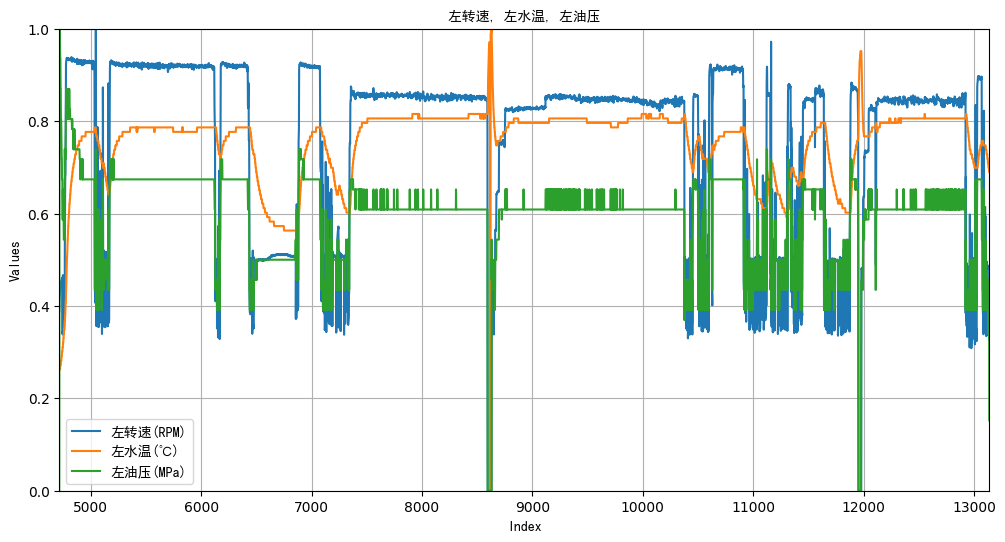

In [6]:
import matplotlib.pyplot as plt

# Select the relevant columns for plotting
columns_to_plot = ['左转速(RPM)', '左水温(℃)', '左油压(MPa)']
data_to_plot = data[columns_to_plot]

# Plotting the data
plt.figure(figsize=(12, 6))
for column in columns_to_plot:
    plt.plot(data_to_plot[column], label=column)

plt.title('左转速, 左水温, 左油压', fontproperties='SimHei')  # Use SimHei font to support Chinese characters
plt.xlabel('Index', fontproperties='SimHei')  # Use SimHei font to support Chinese characters
plt.ylabel('Values', fontproperties='SimHei')  # Use SimHei font to support Chinese characters
plt.legend(prop={'family': 'SimHei'})  # Use SimHei font to support Chinese characters
plt.grid()

# Enable automatic scaling for better observation
plt.autoscale(enable=True, axis='both', tight=True)

plt.show()

